# **BrainHack 2026**

## Table of contents<a id='toc0_'></a>    
- [Setup](#toc2_)    
  - [Install](#toc2_1_)    
    - [For developers](#toc2_1_1_)    
    - [For users](#toc2_1_2_)    
  - [Imports](#toc2_2_)    
  - [Overview](#toc2_3_)    
    - [Pulse](#toc2_3_1_)    
    - [Sequence](#toc2_3_2_)    
    - [System](#toc2_3_3_)    
    - [Simulator](#toc2_3_4_)    
    - [Corrector](#toc2_3_5_)    
    - [Trajector](#toc2_3_6_)    
- [Applications](#toc3_)    
  - [Simulating a single experiment](#toc3_1_)    
    - [Using the `brainhack.simulator.Simulator` class](#toc3_1_1_)    
    - [Using the `brainhack.run.SingleRun` function](#toc3_1_2_)    
      - [Hand parametrized](#toc3_1_2_1_)    
      - [Using a configuration object](#toc3_1_2_2_)    
    - [Using the command line](#toc3_1_3_)    
    - [Example: Computing derivative maps: MT(s/d)R, ihMT, ihMTR, BP, BPR](#toc3_1_4_)    
    - [Example: Computing steady-state signals at every readout](#toc3_1_5_)    
    - [Example: Point Spread Function (PSF)](#toc3_1_6_)    
  - [Simulating many experiments](#toc3_2_)    
    - [Using the `brainhack.run.ManyRuns` function](#toc3_2_1_)    
    - [Example: Computing derivative maps: MT(s/d)R, ihMT, ihMTR, BP, BPR](#toc3_2_2_)    
    - [Example: $\mathrm{B}_1^+$ correction](#toc3_2_3_)    
      - [Manual computation](#toc3_2_3_1_)    
      - [Using `brainhack.corrector.Corrector`](#toc3_2_3_2_)    
  - [Visualization](#toc3_3_)    
    - [Example: $\mathrm{B}_1^+$ correction](#toc3_3_1_)    
      - [1-Dim $\mathrm{B}_1^+$ correction](#toc3_3_1_1_)    
      - [N-Dim $\mathrm{B}_1^+$ correction](#toc3_3_1_2_)    
    - [Example: Steady-state signal with respect to readout](#toc3_3_2_)    
  - [Advanced](#toc3_4_)    
    - [Sensivity Analysis](#toc3_4_1_)    
- [Additional Information](#toc4_)    
  - [Configuration files](#toc4_1_)    
    - [Default configuration](#toc4_1_1_)    
    - [Custom configurations](#toc4_1_2_)    
      - [In a live environment](#toc4_1_2_1_)    
      - [Stored on file](#toc4_1_2_2_)    
  - [Loggers](#toc4_2_)    
  - [The `brainhack.meta.CompositeDictionary` class](#toc4_3_)    
  - [Optimizing `brainhack.run.ManyRuns` runtime](#toc4_4_)    
  - [Test suite](#toc4_5_)    
  - [Contributing new features](#toc4_6_)    
    - [Adding new modules](#toc4_6_1_)    
    - [Modifying existing modules](#toc4_6_2_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc2_'></a>[Setup](#toc0_)

## <a id='toc2_1_'></a>[Install](#toc0_)

### <a id='toc2_1_1_'></a>[For developers](#toc0_)
```bash
    cd brainhack
    pip install -e .
```

### <a id='toc2_1_2_'></a>[For users](#toc0_)
```bash
    cd brainhack
    pip install .
```

## <a id='toc2_2_'></a>[Imports](#toc0_)

In [ ]:
try:  # Basic import example
    from brainhack import (
        Tukey,
        Sequence,
        System,
        Simulator,
        Corrector,
        Trajector,
        Modulation,           # Enum (flag)
        Signal,               # Enum (flag)
        Angle,                # Utility
        Frequency,            # Utility
        CompositeDictionary,  # Utility
        SingleRun,            # Utility
        ManyRuns,             # Utility
    )
    from brainhack.config import default

except ImportError as e:  # If the brainhack package is not installed
    %pip install -e .
    from os import _exit
    _exit(00)

# Additional imports for Applications & later sections
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp

## <a id='toc2_3_'></a>[Overview](#toc0_)

The `brainhack` package aims to provide an interface for simulation and manipulation of (ih)MT signal for varying configurations of MT-preparation pulses, sequences, and biophysical systems. To provide ample space for new features, the package separates each part of the process into different modules:
- MT-preparation pulse classes (e.g., `Tukey`) are declared in the `brainhack.pulse` module,
- the sequence-specifying class `Sequence` is defined in the `brainhack.sequence` module,
- the biophysical system class `System` is in the `brainhack.system` module,
- the simulator class `Simulator` is in the `brainhack.simulator` module,
- the signal correction class `Corrector` is defined in the `brainhack.corrector` module,
- the signal encoding class `Trajector` is defined in the `brainhack.trajector` module,
- some utility features such as the `Signal`, `Angle`, and `Frequency` classes are defined in the `brainhack.meta` module,
- and some utility functions to simplify obtaining results from command line (`SingleRun`) and from batched experiments (`ManyRuns`) are defined in the `brainhack.run` module.

To enhance the user experience, important classes can be directly imported from the `brainhack` namespace. E.g., one can import the `Tukey` class using `from brainhack.pulse import Tukey`, or they can import it using `from brainhack import Tukey` directly. <br>

Below is an object-by-object `Initialization` example of the various classes of the package, with further information on their interplay. The next section shows various example `Applications` of this package, like $\mathrm{B}_1^+$ correction, sensitivity analysis, and visualization. The third and final section contains `Additional Information`, such as defining configuration files for automated analyses and using loggers to manage the package output streams.

### <a id='toc2_3_1_'></a>[Pulse](#toc0_)

In [106]:
pulse = Tukey(
    duration=1e-3,  # in s
    shape=.3,
    flipAngle=299,  # in degree
    offset=7000,    # in Hz
)

### <a id='toc2_3_2_'></a>[Sequence](#toc0_)

In [107]:
sequence = Sequence(
    modulation=Modulation.BP,
    pulse=pulse,
    N_pulsePerOffset=1,
    N_pulse=6,
    N_burst=10,
    N_adc=96,
    N_dummyADC=0,
    dt_interPulse=1.5e-3,  # in s
    TR_burst=100e-3,       # in s
    dt_lastBurst=9e-3,     # in s
    es=6e-3,               # in s
    tr=20,                 # in s
    readout_flipAngle=6,   # in degree
)

### <a id='toc2_3_3_'></a>[System](#toc0_)

In [108]:
system = System(
    pulse=pulse,
    poolFree_M0=1,
    poolBound_M0=0.1,
    poolFree_T1=1,                 # in s
    poolBound_T1=1,                # in s 
    poolBound_T1D=0.01,            # in s
    poolFree_T2=0.1,               # in s
    poolBound_T2=1e-5,             # in s
    poolFreeBound_exchangeRate=20  # in s^-1
)

### <a id='toc2_3_4_'></a>[Simulator](#toc0_)

In [109]:
simulator = Simulator(
    system=system,
    sequence=sequence,
    output_vectorSlice=slice(1),
    export_readMatrix=True,
)

### <a id='toc2_3_5_'></a>[Corrector](#toc0_)

In [110]:
corrector = Corrector.Simple(simulator)

### <a id='toc2_3_6_'></a>[Trajector](#toc0_)

In [111]:
trajector = Trajector.CentricOut_Linear(simulator)

# <a id='toc3_'></a>[Applications](#toc0_)

## <a id='toc3_1_'></a>[Simulating a single experiment](#toc0_)

### <a id='toc3_1_1_'></a>[Using the `brainhack.simulator.Simulator` class](#toc0_)

In [8]:
simulator.SteadyState()

{'MT0': array([1.]),
 'MTs': array([0.82673478]),
 'MTd_CM': array([0.6533915]),
 'MTd_ALT': array([0.66490904]),
 'readout': array([[9.77459365e-01, 1.11744793e-01, 0.00000000e+00, 5.98203595e-03],
        [1.11132643e-02, 8.82273171e-01, 0.00000000e+00, 5.98203595e-04],
        [0.00000000e+00, 0.00000000e+00, 5.48811636e-01, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00]])}

### <a id='toc3_1_2_'></a>[Using the `brainhack.run.SingleRun` function](#toc0_)

#### <a id='toc3_1_2_1_'></a>[Hand parametrized](#toc0_)

In [9]:
SingleRun(
    # Pulse
    pw=1e-3,        # in s
    r_tukey=.3,
    fa_sat=200,     # in degree
    offset=7000,    # in Hz
    # Sequence
    FLAG_Sine_Modulation='BP',
    N_altern=1,
    np=4,
    nb=10,
    turbo=80,
    N_dummyADC=3,
    dt=1.5e-3,      # in s
    btr=100e-3,     # in s
    btrlast=1e-3,   # in s
    es=6e-3,        # in s
    tr=3,          # in s
    fa_rage=5,      # in degree
    # System
    M0a=1,
    M0b=0.1,
    T1f=1,          # in s
    T2f=0.1,        # in s
    T1b=1,          # in s 
    T1D=0.01,       # in s
    T2b=1e-5,       # in s
    R=10,           # in s^-1
    # Simulator
    output_fullVector=True,
    export_read=True,
    # Output
    outputDir='./output/',
    filePrefix='',
    export=False,
)

{'MT0': array([0.97320366, 0.09829085, 0.        , 1.        ]),
 'MTs': array([8.59023139e-01, 6.19723931e-02, 2.57624959e-07, 1.00000000e+00]),
 'MTd_CM': array([0.79585404, 0.04262518, 0.        , 1.        ]),
 'MTd_ALT': array([ 8.00265008e-01,  4.38997033e-02, -4.44383964e-08,  1.00000000e+00]),
 'readout': array([[9.84485836e-01, 5.77155166e-02, 0.00000000e+00, 5.98203595e-03],
        [5.74958916e-03, 9.36302447e-01, 0.00000000e+00, 5.98203595e-04],
        [0.00000000e+00, 0.00000000e+00, 5.48811636e-01, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00]])}

#### <a id='toc3_1_2_2_'></a>[Using a configuration object](#toc0_)

In [10]:
SingleRun(**default['run'])

{'MT0': array([0.97320366, 0.09829085, 0.        , 1.        ]),
 'MTs': array([8.59023139e-01, 6.19723931e-02, 2.57624959e-07, 1.00000000e+00]),
 'MTd_CM': array([0.79585404, 0.04262518, 0.        , 1.        ]),
 'MTd_ALT': array([ 8.00265008e-01,  4.38997033e-02, -4.44383964e-08,  1.00000000e+00]),
 'readout': array([[9.84485836e-01, 5.77155166e-02, 0.00000000e+00, 5.98203595e-03],
        [5.74958916e-03, 9.36302447e-01, 0.00000000e+00, 5.98203595e-04],
        [0.00000000e+00, 0.00000000e+00, 5.48811636e-01, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00]])}

### <a id='toc3_1_3_'></a>[Using the command line](#toc0_)

In [11]:
!python brainhack/run.py ./brainhack/configs/default.yaml

2026-05-21 00:44:13,169 - root - INFO - MT0: [0.9732036610707329, 0.09829085279876042, 0.0, 1.0]
2026-05-21 00:44:13,170 - root - INFO - MTs: [0.8590231386198169, 0.0619723931199686, 2.5762495879556483e-07, 1.0]
2026-05-21 00:44:13,170 - root - INFO - MTd_CM: [0.7958540383587304, 0.04262518348196712, 0.0, 1.0]
2026-05-21 00:44:13,170 - root - INFO - MTd_ALT: [0.8002650081321153, 0.043899703281803405, -4.44383963520833e-08, 1.0]
2026-05-21 00:44:13,170 - root - INFO - readout: [[0.984485836436591, 0.05771551658429958, 0.0, 0.005982035946064735], [0.005749589161890545, 0.9363024474696356, 0.0, 0.0005982035946064736], [0.0, 0.0, 0.5488116360940265, 0.0], [0.0, 0.0, 0.0, 1.0]]


### <a id='toc3_1_4_'></a>[Example: Computing derivative maps: MT(s/d)R, ihMT, ihMTR, BP, BPR](#toc0_)

In [12]:
data = SingleRun(**default['run'])
del data['readout']

data = CompositeDictionary(data)

with np.errstate(divide='ignore', invalid='ignore'):
    for key in Signal.values():
        print(str(key.name).rjust(9), data[key].tolist(), sep=' = ')

      MT0 = [0.9732036610707329, 0.09829085279876042, 0.0, 1.0]
      MTs = [0.8590231386198169, 0.0619723931199686, 2.5762495879556483e-07, 1.0]
   MTd_CM = [0.7958540383587304, 0.04262518348196712, 0.0, 1.0]
  MTd_ALT = [0.8002650081321153, 0.043899703281803405, -4.44383963520833e-08, 1.0]
  ihMT_CM = [0.12633820052217315, 0.03869441927600295, 5.152499175911297e-07, 0.0]
 ihMT_ALT = [0.11751626097540324, 0.036145379676330386, 6.041267102952962e-07, 0.0]
       BP = [0.008821939546769908, 0.0025490395996725645, -8.88767927041666e-08, 0.0]
     MTsR = [11.73243864755841, 36.949989388279924, -inf, 0.0]
  MTdR_CM = [18.223279443572977, 56.63362126968474, nan, 0.0]
 MTdR_ALT = [17.770037234379913, 55.33693926566782, inf, 0.0]
 ihMTR_CM = [12.981681592029155, 39.367263762809614, inf, 0.0]
ihMTR_ALT = [12.075197173642989, 36.77389975477578, inf, 0.0]
      BPR = [0.906484418386166, 2.5933640080338294, -inf, 0.0]


### <a id='toc3_1_5_'></a>[Example: Computing steady-state signals at every readout](#toc0_)

In [13]:
data = SingleRun(**default['run'])
invReadout = np.linalg.inv(data['readout'])
readouts = {
    key: [np.linalg.matrix_power(invReadout, default['run']['N_dummyADC']) @ data[key]]
    for key in data if key != 'readout'
}
for key in readouts.keys():
    for i in range(1, default['run']['turbo']):
        readouts[key].append(data['readout'] @ readouts[key][-1])

readouts = CompositeDictionary(readouts)

with np.errstate(divide='ignore', invalid='ignore'):
    for key in Signal.values():
        print(str(key.name).rjust(9), readouts[key].T.tolist(), sep=' = ')

      MT0 = [[0.9838497249170115, 0.9802464948203895, 0.976698476318138, 0.9732036610707329, 0.9697601635832297, 0.9663662127927547, 0.9630201442417339, 0.959720392795983, 0.9564654858696381, 0.9532540371215568, 0.9500847405902929, 0.9469563652370405, 0.9438677498680818, 0.9408177984102596, 0.9378054755148427, 0.9348298024668739, 0.9318898533786868, 0.9289847516477687, 0.9261136666605273, 0.923275810724808, 0.9204704362152062, 0.9176968329163319, 0.9149543255502196, 0.9122422714750422, 0.9095600585431807, 0.9069071031075389, 0.904282848165766, 0.9016867616327711, 0.8991183347325857, 0.8965770805012555, 0.8940625323930198, 0.8915742429825818, 0.8891117827567728, 0.8866747389893792, 0.8842627146933407, 0.8818753276449276, 0.8795122094748835, 0.8771730048218708, 0.8748573705438786, 0.8725649749835592, 0.8702954972837372, 0.8680486267496007, 0.8658240622543253, 0.863621511685109, 0.8614406914268085, 0.8592813258805589, 0.8571431470149499, 0.8550258939474887, 0.8529293125542521, 0.850853155

### <a id='toc3_1_6_'></a>[Example: Point Spread Function (PSF)](#toc0_)

## <a id='toc3_2_'></a>[Simulating many experiments](#toc0_)

### <a id='toc3_2_1_'></a>[Using the `brainhack.run.ManyRuns` function](#toc0_)

In [ ]:
sim = simulator.copy()
sim.export_readMatrix = False
data = {key: [] for key in Signal.keys()}
ManyRuns(
    sim,
    ['poolFree_T1', 'flipAngle'],
    {
        'poolFree_T1': [1.0, 1.5, 2.0],
        'flipAngle': simulator.pulse.flipAngle * np.linspace(.1, 1.5, 36)
    },
    data,
    safe=True,
)
for key, val in data.items():
    if val:
        print(key.rjust(7), np.array(val).tolist(), sep=' = ')

    MT0 = [0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999995770434952, 0.9999995770434952, 0.9999995770434952, 0.9999995770434952, 0.9999995770434952, 0.9999995770434952, 0.9999995770434952, 0.9999995770434952, 0.9999995770434952, 0.9999995770434952, 0.9999995770434952, 0.9999995770434952, 0.9999995770434952, 0.9999995

### <a id='toc3_2_2_'></a>[Example: Computing derivative maps: MT(s/d)R, ihMT, ihMTR, BP, BPR](#toc0_)

In [15]:
data = CompositeDictionary(data)

with np.errstate(divide='ignore', invalid='ignore'):
    for key in Signal.values():
        print(str(key.name).rjust(9), data[key].tolist(), sep=' = ')

      MT0 = [0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999999989204701, 0.9999995770434952, 0.9999995770434952, 0.9999995770434952, 0.9999995770434952, 0.9999995770434952, 0.9999995770434952, 0.9999995770434952, 0.9999995770434952, 0.9999995770434952, 0.9999995770434952, 0.9999995770434952, 0.9999995770434952, 0.9999995770434952, 0.99999

### <a id='toc3_2_3_'></a>[Example: $\mathrm{B}_1^+$ correction](#toc0_)

#### <a id='toc3_2_3_1_'></a>[Manual computation](#toc0_)

In [124]:
# Initializing variables
flipAngle_nominal = simulator.pulse.flipAngle
B1rel_range = np.linspace(.1, 1.5, 141)
ihMTR_values = []

# Simulating ihMTR throughout the interpolation range
# by changing the simulator's pulse flip angle
for B1rel in B1rel_range:
    simulator.pulse.flipAngle = flipAngle_nominal * B1rel
    out = simulator.SteadyState()
    ihMTR_values.append( 200 * (out['MTs'][0] - out['MTd_CM'][0]) / out['MT0'][0] )

# Restoring original flip angle to simulator's pulse
simulator.pulse.flipAngle = flipAngle_nominal

# Generating the interpolator of ihMTR_CM dependency on B1+
interpolator = sp.interpolate.PchipInterpolator(flipAngle_nominal * B1rel_range, ihMTR_values)

# Creating fake data to correct
FA = np.random.random((2, 2, 3)) * flipAngle_nominal * (max(B1rel_range) - min(B1rel_range)) + flipAngle_nominal * min(B1rel_range)
fake_data = {Signal.ihMTR_CM: interpolator(FA).reshape((2, 2, 3))}
corrected = corrector.apply({'flipAngle': FA}, fake_data)

# Checking the fake and corrected data shape & values
print('Shape')
print('fake_data:', fake_data[Signal.ihMTR_CM].shape)
print('corrected:', corrected[Signal.ihMTR_CM].shape)

print()

print('Value pairs (original, corrected)')
print(*list(zip(fake_data[Signal.ihMTR_CM].flatten(), corrected[Signal.ihMTR_CM].flatten())), sep='\n')

Shape
fake_data: (2, 2, 3)
corrected: (2, 2, 3)

Value pairs (original, corrected)
(np.float64(12.114041920462645), np.float64(34.66865583202186))
(np.float64(39.847281040173414), np.float64(34.66865583202186))
(np.float64(19.652419568579226), np.float64(34.66865583202187))
(np.float64(3.253498399514764), np.float64(34.668655832021855))
(np.float64(37.14263790600941), np.float64(34.66865583202187))
(np.float64(11.785741071002914), np.float64(34.66865583202186))
(np.float64(37.00823855507489), np.float64(34.66865583202186))
(np.float64(37.344473181248446), np.float64(34.66865583202187))
(np.float64(2.103790787357714), np.float64(34.66865583202187))
(np.float64(34.97389091972717), np.float64(34.66865583202186))
(np.float64(0.48345764589182744), np.float64(34.66865583202186))
(np.float64(34.800192977236655), np.float64(34.66865583202186))


#### <a id='toc3_2_3_2_'></a>[Using `brainhack.corrector.Corrector`](#toc0_)

In [150]:
# Generating the interpolator of ihMTR_CM dependency on B1+
interpolant = corrector.interpolants[Signal.ihMTR_CM]

# Creating fake data to correct
FA = np.random.random((2, 2, 3)) * (max(corrector.ranges['flipAngle']) - min(corrector.ranges['flipAngle'])) + min(corrector.ranges['flipAngle'])
fake_data = {Signal.ihMTR_CM: interpolant(FA).reshape((2, 2, 3))}
corrected = corrector.apply({'flipAngle': FA}, fake_data)

# Checking the fake and corrected data shape & values
print('Shape')
print('fake_data:', fake_data[Signal.ihMTR_CM].shape)
print('corrected:', corrected[Signal.ihMTR_CM].shape)

print()

print('Value pairs (original, corrected)')
print(*list(zip(fake_data[Signal.ihMTR_CM].flatten(), corrected[Signal.ihMTR_CM].flatten())), sep='\n')

Shape
fake_data: (2, 2, 3)
corrected: (2, 2, 3)

Value pairs (original, corrected)
(np.float64(22.706343568488148), np.float64(34.66865583202187))
(np.float64(30.94879040362071), np.float64(34.66865583202187))
(np.float64(8.337198314719954), np.float64(34.66865583202187))
(np.float64(38.57790522830083), np.float64(34.66865583202187))
(np.float64(32.87010930532259), np.float64(34.66865583202187))
(np.float64(14.674461570641059), np.float64(34.66865583202187))
(np.float64(23.861892492629423), np.float64(34.66865583202187))
(np.float64(1.1413646459249893), np.float64(34.66865583202187))
(np.float64(20.50623576229162), np.float64(34.66865583202187))
(np.float64(39.552451198289745), np.float64(34.66865583202187))
(np.float64(3.8736080214221347), np.float64(34.66865583202187))
(np.float64(39.88317388727001), np.float64(34.66865583202187))


## <a id='toc3_3_'></a>[Visualization](#toc0_)

### <a id='toc3_3_1_'></a>[Example: $\mathrm{B}_1^+$ correction](#toc0_)

#### <a id='toc3_3_1_1_'></a>[1-Dim $\mathrm{B}_1^+$ correction](#toc0_)

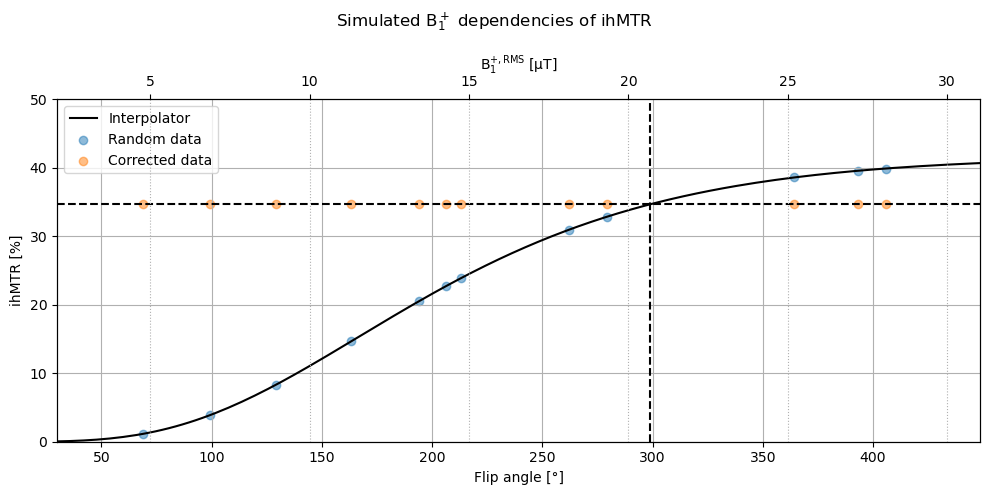

In [166]:
# 1D plotting of ihMTR = f(B1+)
x = corrector.ranges['flipAngle']
xb = (x / corrector.simulator.pulse.flipAngle) * simulator.pulse.b1RMS

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(x, ihMTR_values,'k', label=f'Interpolator')

ax.scatter(FA.flatten(), fake_data[Signal.ihMTR_CM].flatten(), label='Random data', alpha=.5)
ax.scatter(FA.flatten(), corrected[Signal.ihMTR_CM].flatten(), label='Corrected data', alpha=.5)

ax.vlines(corrector.simulator.pulse.flipAngle, 0, 50, 'k', 'dashed')
ax.hlines(corrector.nominals[Signal.ihMTR_CM], min(x), max(x), 'k', 'dashed')

ax.set_xlabel('Flip angle [°]')
ax.set_xlim(min(x), max(x))
ax.set_ylim(0, 50)
ax.set_ylabel('ihMTR [%]')

ax.legend()
ax.grid()

fig.suptitle(r'Simulated $\mathrm{B}_1^+$ dependencies of ihMTR')

ax2 = ax.twiny()
ax2.set_xlim(min(xb) * 1e6, max(xb) * 1e6)
ax2.set_xlabel(r'$\mathrm{B}_1^\mathrm{+,RMS}$ [µT]')
ax2.grid(linestyle='dotted')

fig.tight_layout()
plt.show()

#### <a id='toc3_3_1_2_'></a>[N-Dim $\mathrm{B}_1^+$ correction](#toc0_)

In [168]:
# Create an N-Dim corrector and retrieve the ihMTR_CM interpolant
nd_corrector = Corrector(simulator, {'poolFree_T1': np.array([1, 1.5, 2.]), 'flipAngle': simulator.pulse.flipAngle * np.linspace(.1, 1.5, 146)})
nominals = nd_corrector.nominals
interp = nd_corrector.interpolants[Signal.ihMTR_CM]

# Some fine tuning for the plot
test_interpolate_for_T1 = 1.25
x = nd_corrector.mesh['flipAngle'].T.squeeze()
ranges = np.vstack([test_interpolate_for_T1 * np.ones_like(x), x]).T

# Creating fake data to correct
shape = (5, 5, 5)
T1 = np.random.random(shape) * (max(nd_corrector.ranges['poolFree_T1']) - min(nd_corrector.ranges['poolFree_T1'])) + min(nd_corrector.ranges['poolFree_T1'])
B1 = np.random.random(shape) * (max(nd_corrector.ranges['flipAngle']) - min(nd_corrector.ranges['flipAngle'])) + min(nd_corrector.ranges['flipAngle'])
params = {'flipAngle': B1, 'poolFree_T1': T1}
data = {Signal.ihMTR_CM: interp(np.vstack([T1.flatten(), B1.flatten()]).T).reshape(shape)}
corrected = nd_corrector.apply(params, data)

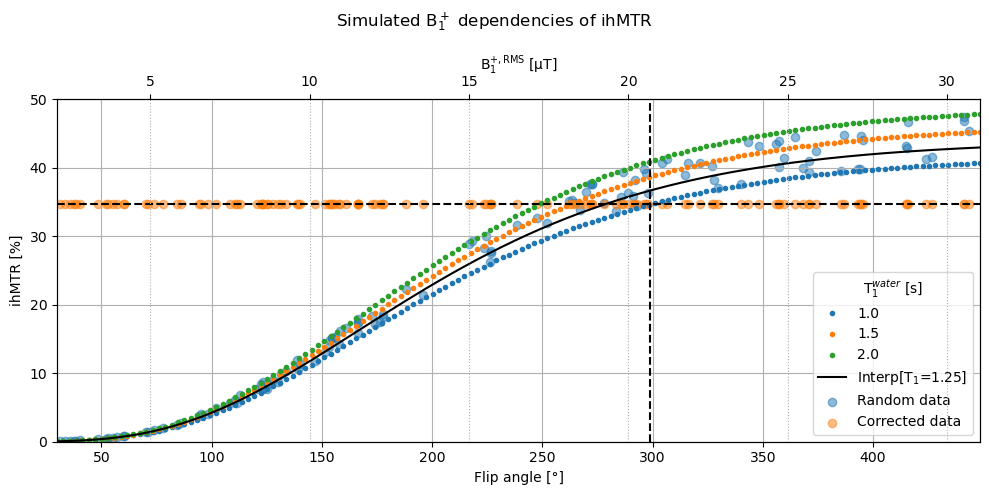

In [169]:
# 2D plotting of ihMTR = f(B1+) for various values of T1_water
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(x, nd_corrector.simulated[Signal.ihMTR_CM].T, '.', label=nd_corrector.ranges['poolFree_T1'])
ax.plot(x, interp(ranges), color='k', label=r'Interp[$\mathrm{T}_1$=' + f'{test_interpolate_for_T1}]')

ax.scatter(B1.flatten(), data[Signal.ihMTR_CM].flatten(), label='Random data', alpha=.5)
ax.scatter(B1.flatten(), corrected[Signal.ihMTR_CM].flatten(), label='Corrected data', alpha=.5)

ax.vlines(simulator.pulse.flipAngle, 0, 50, 'k', 'dashed')
ax.hlines(nominals[Signal.ihMTR_CM], min(nd_corrector.ranges['flipAngle']), max(nd_corrector.ranges['flipAngle']), 'k', 'dashed')

ax.legend(title=r'$\mathrm{T}_1^{water}$ [s]')
ax.set_xlabel('Flip angle [°]')
ax.set_xlim(min(nd_corrector.ranges['flipAngle']), max(nd_corrector.ranges['flipAngle']))

ax.set_ylim(0, 50)
ax.set_ylabel('ihMTR [%]')

ax.grid()

ax2 = ax.twiny()
ax2.set_xlim(.1e6 * simulator.pulse.b1RMS, 1.5e6 * simulator.pulse.b1RMS)
ax2.set_xlabel(r'$\mathrm{B}_1^\mathrm{+,RMS}$ [µT]')
ax2.grid(linestyle='dotted')

fig.suptitle(r'Simulated $\mathrm{B}_1^+$ dependencies of ihMTR')
fig.tight_layout()
plt.show()

### <a id='toc3_3_2_'></a>[Example: Steady-state signal with respect to readout](#toc0_)

In [ ]:
# x = range(1, sequence_noDummy.N_adc + 1)

# fig, axes = plt.subplots(2, 6, sharex=True, figsize=(32, 8))
# axes = axes.flatten()

# axes[0].set_title("$MT_0$")
# axes[0].grid()
# axes[0].set_ylim(0, 1)
# axes[0].plot(x, allMT0[:,0:2])
# axes[0].set_xlim(1, sequence_noDummy.N_adc)
# axes[0 + 6].remove()

# axes[1].set_title("$MT_s$")
# axes[1].grid()
# axes[1].set_ylim(0, 1)
# axes[1].plot(x, allMTs[:,0:2])
# axes[1 + 6].set_title("$MTR_s$")
# axes[1 + 6].grid()
# axes[1 + 6].set_ylim(0, 40)
# axes[1 + 6].plot(x, allMTRs[:,0:2])

# axes[2].set_title("$MT_d^{CM}$")
# axes[2].grid()
# axes[2].set_ylim(0, 1)
# axes[2].plot(x, allMTds[0][:,0:2])
# axes[2 + 6].set_title("$MTR_d^{CM}$")
# axes[2 + 6].grid()
# axes[2 + 6].set_ylim(0, 40)
# axes[2 + 6].plot(x, allMTRds[0][:,0:2])

# axes[3].set_title("$MT_d^{ALT}$")
# axes[3].grid()
# axes[3].set_ylim(0, 1)
# axes[3].plot(x, allMTds[1][:,0:2])
# axes[3 + 6].set_title("$MTR_d^{ALT}$")
# axes[3 + 6].grid()
# axes[3 + 6].set_ylim(0, 40)
# axes[3 + 6].plot(x, allMTRds[1][:,0:2])

# axes[4].set_title("$ihMT_d^{CM}$")
# axes[4].grid()
# axes[4].set_ylim(0, .40)
# axes[4].plot(x, allihMTs[0][:,0:2])
# axes[4 + 6].set_title("$ihMTR_d^{CM}$")
# axes[4 + 6].grid()
# axes[4 + 6].set_ylim(0, 40)
# axes[4 + 6].plot(x, allihMTRs[0][:,0:2])

# axes[5].set_title("$ihMT_d^{ALT}$")
# axes[5].grid()
# axes[5].set_ylim(0, .40)
# axes[5].plot(x, allihMTs[1][:,0:2])
# axes[5 + 6].set_title("$ihMTR_d^{ALT}$")
# axes[5 + 6].grid()
# axes[5 + 6].set_ylim(0, 40)
# axes[5 + 6].plot(x, allihMTRs[1][:,0:2])

# plt.show()

In [ ]:
# x = range(1, sequence_noDummy.N_adc + 1)

# fig, axes = plt.subplots(1, 2, sharex=True, figsize=(20, 5))
# axes = axes.flatten()

# axes[0].plot(x, allMT0.T[0], color='C0', linestyle='dotted', label='MT0')
# axes[0].plot(x, allMTs.T[0], color='C2', linestyle='-.', label='MTs')
# axes[0].plot(x, allMTds[0].T[0], color='k', linestyle='--', label='MTd CM')
# axes[0].plot(x, allMTds[1].T[0], color='C3', linestyle='--', label='MTd ALT')
# axes[0].plot(x, allihMTs[0].T[0], color='k', linestyle='-', label='ihMT CM')
# axes[0].plot(x, allihMTs[1].T[0], color='C3', linestyle='-', label='ihMT ALT')

# axes[1].plot(x, allMTRs.T[0], color='C2', linestyle='-.', label='MTRs')
# axes[1].plot(x, allMTRds[0].T[0], color='k', linestyle='--', label='MTRd CM')
# axes[1].plot(x, allMTRds[1].T[0], color='C3', linestyle='--', label='MTRd ALT')
# axes[1].plot(x, .5 * allihMTRs[0].T[0], color='k', linestyle='-', label='ihMTR CM')
# axes[1].plot(x, .5 * allihMTRs[1].T[0], color='C3', linestyle='-', label='ihMTR ALT')

# axes[0].legend()
# axes[0].grid()
# axes[0].set_xlabel('# adc')
# axes[0].set_xlim(1, sequence_noDummy.N_adc)
# axes[0].set_ylabel('(ih)MT [a.u.]')
# axes[0].set_ylim(0, 1)

# axes[1].legend()
# axes[1].grid()
# axes[1].set_xlabel('# adc')
# axes[1].set_xlim(1, sequence_noDummy.N_adc)
# axes[1].set_ylabel('(ih)MTR [%]')
# axes[1].set_ylim(0, 40)

# plt.show()

## <a id='toc3_4_'></a>[Advanced](#toc0_)

### <a id='toc3_4_1_'></a>[Sensivity Analysis](#toc0_)

# <a id='toc4_'></a>[Additional Information](#toc0_)

## <a id='toc4_1_'></a>[Configuration files](#toc0_)

### <a id='toc4_1_1_'></a>[Default configuration](#toc0_)

In [ ]:
for key, val in default.items():
    print(f'\033[1m{key}\033[0m')
    for kkey, vval in val.items():
        if type(vval) != dict:
            print(str(kkey).rjust(len('disable_existing_loggers')), ':', repr(vval))
        else:
            print(f'\t\033[1m{kkey}\033[0m')
            for kkkey, vvval in vval.items():
                print('\t\t', kkkey, repr(vvval))
    print()

### <a id='toc4_1_2_'></a>[Custom configurations](#toc0_)

#### <a id='toc4_1_2_1_'></a>[In a live environment](#toc0_)

#### <a id='toc4_1_2_2_'></a>[Stored on file](#toc0_)

## <a id='toc4_2_'></a>[Loggers](#toc0_)

## <a id='toc4_3_'></a>[The `brainhack.meta.CompositeDictionary` class](#toc0_)

## <a id='toc4_4_'></a>[Optimizing `brainhack.run.ManyRuns` runtime](#toc0_)

## <a id='toc4_5_'></a>[Test suite](#toc0_)


## <a id='toc4_6_'></a>[Contributing new features](#toc0_)

### <a id='toc4_6_1_'></a>[Adding new modules](#toc0_)

### <a id='toc4_6_2_'></a>[Modifying existing modules](#toc0_)